In [69]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/abhirana011/dataset-for-cnn/train.csv
/kaggle/input/datasets/abhirana011/dataset-for-cnn/test.csv


# Libraries

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout

In [71]:
train = pd.read_csv("/kaggle/input/datasets/abhirana011/dataset-for-cnn/train.csv") 
test = pd.read_csv("/kaggle/input/datasets/abhirana011/dataset-for-cnn/test.csv")

In [72]:
train.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# EDA

In [73]:
train.isnull().sum()
test.isnull().sum()

pixel0      0
pixel1      0
pixel2      0
pixel3      0
pixel4      0
           ..
pixel779    0
pixel780    0
pixel781    0
pixel782    0
pixel783    0
Length: 784, dtype: int64

In [74]:
train['label'].unique()

array([1, 0, 4, 7, 3, 5, 8, 9, 2, 6])

In [75]:
train['label'].value_counts().sort_index()

label
0    4132
1    4684
2    4177
3    4351
4    4072
5    3795
6    4137
7    4401
8    4063
9    4188
Name: count, dtype: int64

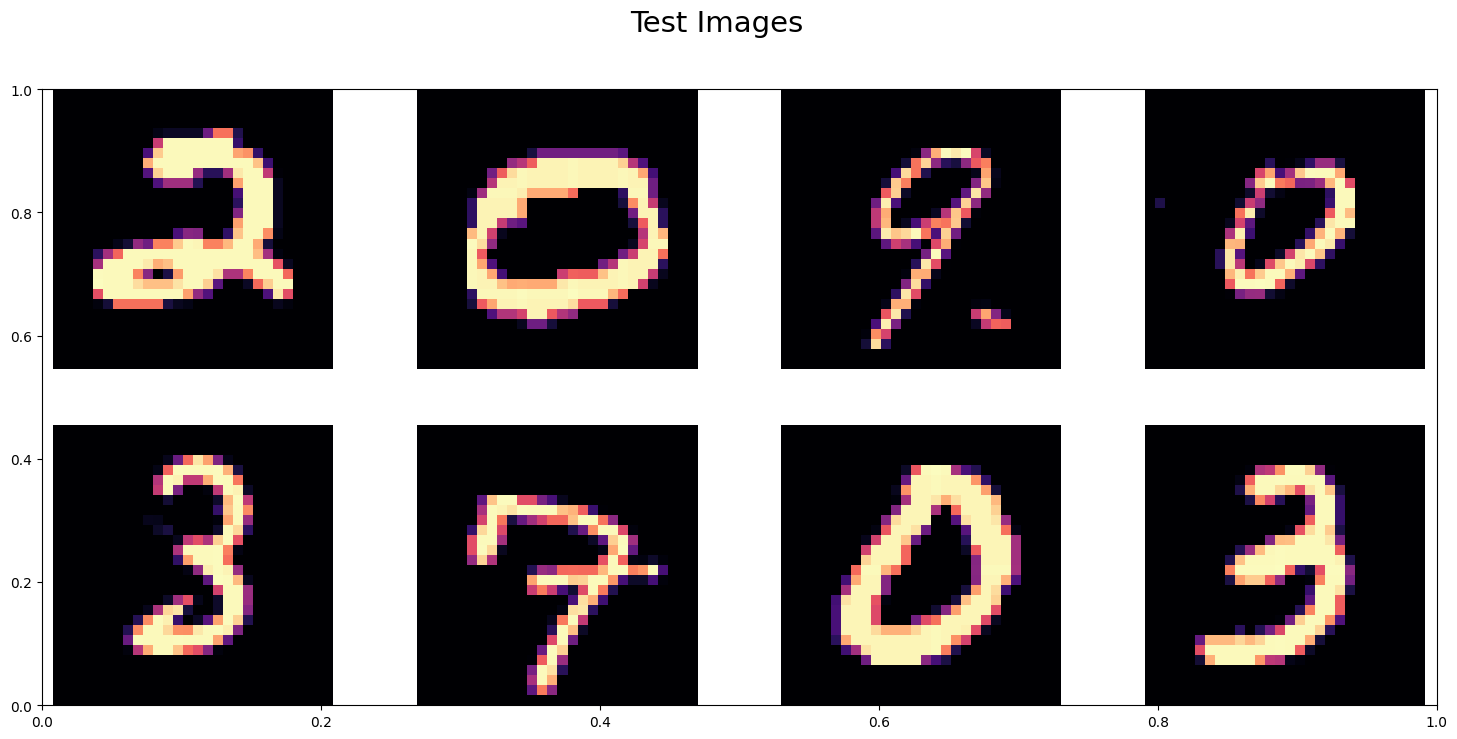

In [76]:
fig, ax=plt.subplots(figsize=(18,8))
for ind, row in test.iloc[:8,:].iterrows():
    plt.subplot(2,4,ind+1)
    img = row.to_numpy()[:].reshape(28,28)
    fig.suptitle('Test Images',fontsize=21)
    plt.axis('off')
    plt.imshow(img, cmap='magma')

# Procesing

In [77]:
X= train.iloc[:, 1:].to_numpy()
y= train['label'].to_numpy()

test = test.loc[: , :].to_numpy()

for i in [X, y, test]:
    print(i.shape)

(42000, 784)
(42000,)
(28000, 784)


# Normalize the data

In [78]:
X = X/ 255.0
test = test /255.0

# Reshape Dataset

In [79]:
print(X.shape)
print(test.shape)
X=X.reshape(-1,28,28,1)
test = test.reshape(-1,28,28,1)
print(X.shape)
print(test.shape)

(42000, 784)
(28000, 784)
(42000, 28, 28, 1)
(28000, 28, 28, 1)


In [80]:
#Shape and vlaue of target
print(y.shape)
print(y[0])


#ocnvert y_train to categorial by one hot encoding
y_enc = to_categorical(y, num_classes =10)

#shape and values of target
print(y_enc.shape)
print(y_enc[0])

(42000,)
1
(42000, 10)
[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]


# Train test split

In [81]:
random_seed =2

X_train, X_val, y_train_enc, y_val_enc =train_test_split(X, y_enc, test_size=41)

for i in [X_train, y_train_enc, X_val, y_val_enc]:
    print(i.shape)

(41959, 28, 28, 1)
(41959, 10)
(41, 28, 28, 1)
(41, 10)


# Plot image

[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]


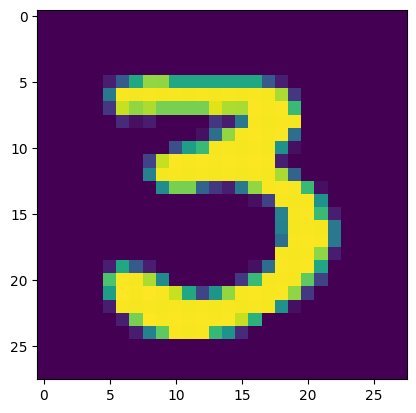

In [82]:
g = plt.imshow(X_train[0][:,:,0])
print(y_train_enc[0])

# CNN

Model parameter

In [83]:
INPUT_SHAPE =(28,28,1)
OUTPUT_SHAPE =10
BATCH_SIZE =128
EPOCHS =10
VERBOSE = 2